# Conditional Autoencoder Approach, Experiment 1

We train an conditional beta variational autoencoder on the trajectory data with hand-engineered features. 
We attempt to encode entire trajectories into the latent variable.
The conditioning is on 



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import os

# --- Config
USE_GLOBAL_ZSCORE = False
DRY_RUN = False #os.getenv("USER") == "polya"

# --- Device ---
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"User: {os.getenv('USER')} | Device: {device} | DRY_RUN: {DRY_RUN} | Global Z-score: {USE_GLOBAL_ZSCORE}")

User: polya | Device: mps | DRY_RUN: False | Global Z-score: False


# Wrangling data

In [2]:
import numpy as np
import pandas as pd
from notebooks.experiment.preprocessing import load_and_clean, make_windows, DEFAULT_STIM_COLS

df = pd.read_parquet("dataset.parquet")

# Use all features (default), or pick a subset:
# stim_cols = ["u_t", "m_t", "recency"]
erk, stim, metadata = make_windows(df, window_size=40, stride=20)

print(f"Windows: {erk.shape[0]}, Timepoints: {erk.shape[1]}")
print(f"Stim features: {len(DEFAULT_STIM_COLS)} channels — {DEFAULT_STIM_COLS}")
print(f"Stim shape: {stim.shape}")  # expect (n_windows, 9, 40)
print(f"\nSamples per experiment:")
print(metadata["ramp_pattern_name"].value_counts())

Windows: 11443, Timepoints: 40
Stim features: 9 channels — ['u_t', 'm_t', 'recency', 'ewma_fast', 'ewma_slow', 'n_5', 'slope_5', 'burst_pos', 's_cum']
Stim shape: (11443, 9, 40)

Samples per experiment:
ramp_pattern_name
3-2-1minIntervals    6118
Sustained            3659
ramp1                1300
Single                366
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

# Split by unique cell ID, stratified by experiment to keep proportions balanced
uid_meta = metadata.drop_duplicates("uid")[["uid", "ramp_pattern_name"]]
uids_train, uids_test = train_test_split(
    uid_meta["uid"], test_size=0.2, random_state=42,
    stratify=uid_meta["ramp_pattern_name"]
)
uid_meta_train = uid_meta[uid_meta["uid"].isin(uids_train)]
uids_train, uids_val = train_test_split(
    uid_meta_train["uid"], test_size=0.125, random_state=42,
    stratify=uid_meta_train["ramp_pattern_name"]
)

mask_train = metadata["uid"].isin(uids_train).values
mask_val = metadata["uid"].isin(uids_val).values
mask_test = metadata["uid"].isin(uids_test).values

erk_train, stim_train = erk[mask_train], stim[mask_train]
erk_val, stim_val = erk[mask_val], stim[mask_val]
erk_test, stim_test = erk[mask_test], stim[mask_test]

print(f"Train: {erk_train.shape[0]}  Val: {erk_val.shape[0]}  Test: {erk_test.shape[0]}")
print(f"\nPer-experiment breakdown:")
for split_name, mask in [("train", mask_train), ("val", mask_val), ("test", mask_test)]:
    counts = metadata.loc[mask, "ramp_pattern_name"].value_counts()
    print(f"  {split_name}: {dict(counts)}")

Train: 8011  Val: 1143  Test: 2289

Per-experiment breakdown:
  train: {'3-2-1minIntervals': np.int64(4283), 'Sustained': np.int64(2563), 'ramp1': np.int64(909), 'Single': np.int64(256)}
  val: {'3-2-1minIntervals': np.int64(612), 'Sustained': np.int64(367), 'ramp1': np.int64(127), 'Single': np.int64(37)}
  test: {'3-2-1minIntervals': np.int64(1223), 'Sustained': np.int64(729), 'ramp1': np.int64(264), 'Single': np.int64(73)}


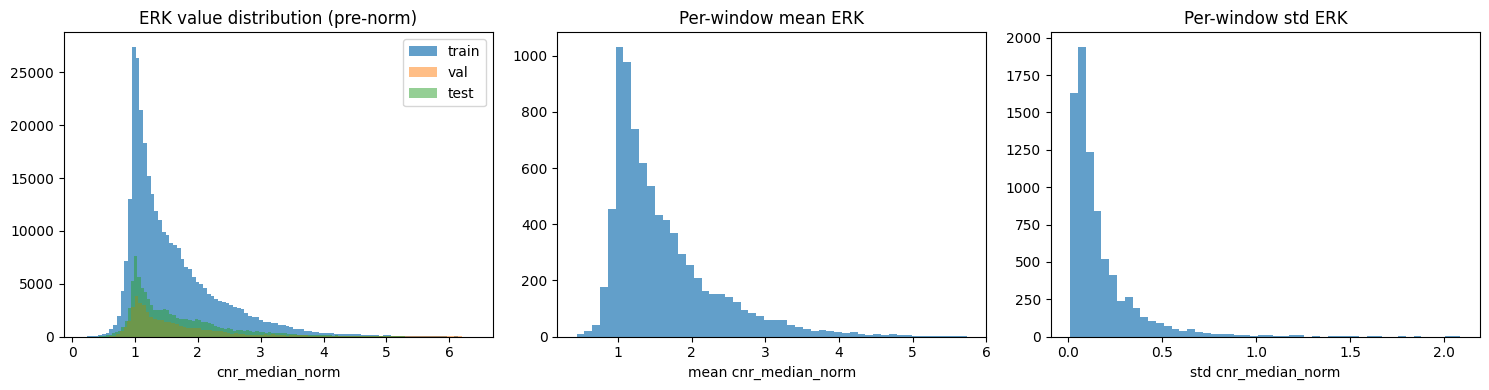

Train ERK — mean: 1.6059, std: 0.7544, min: 0.1743, max: 6.1429


In [4]:
# --- Pre-normalisation distribution ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(erk_train.ravel(), bins=100, alpha=0.7, label="train")
axes[0].hist(erk_val.ravel(), bins=100, alpha=0.5, label="val")
axes[0].hist(erk_test.ravel(), bins=100, alpha=0.5, label="test")
axes[0].set_title("ERK value distribution (pre-norm)")
axes[0].set_xlabel("cnr_median_norm")
axes[0].legend()

axes[1].hist(erk_train.mean(axis=1), bins=50, alpha=0.7)
axes[1].set_title("Per-window mean ERK")
axes[1].set_xlabel("mean cnr_median_norm")

axes[2].hist(erk_train.std(axis=1), bins=50, alpha=0.7)
axes[2].set_title("Per-window std ERK")
axes[2].set_xlabel("std cnr_median_norm")

plt.tight_layout()
plt.show()

print(f"Train ERK — mean: {erk_train.mean():.4f}, std: {erk_train.std():.4f}, "
      f"min: {erk_train.min():.4f}, max: {erk_train.max():.4f}")

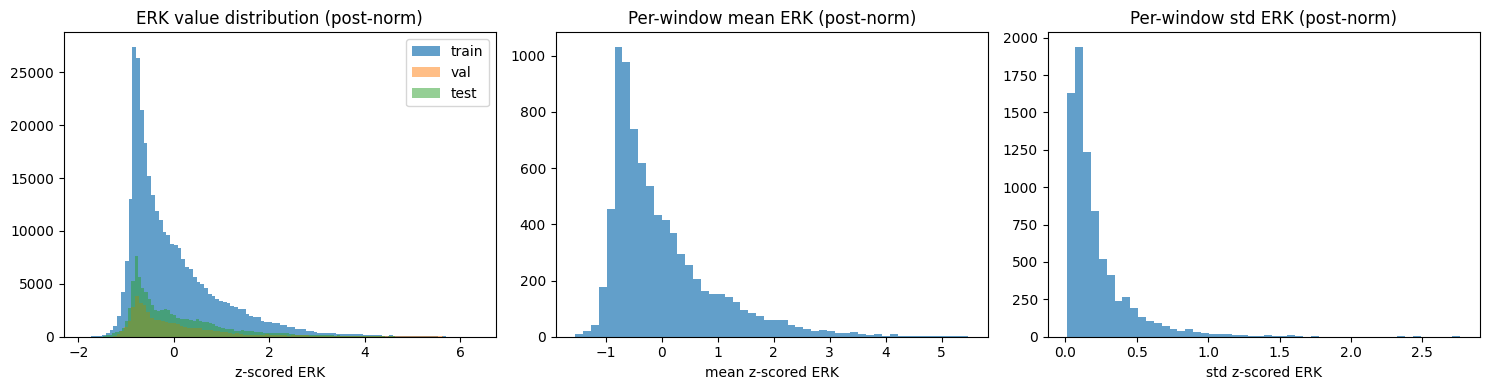

Train ERK (normed) — mean: -0.0000, std: 1.0000, min: -1.8976, max: 6.0137

Normalisation params (save these for inference): mu=1.6059, sigma=0.7544


In [5]:
# --- Global z-score normalisation (fit on train only) ---
erk_mu = erk_train.mean()
erk_sigma = erk_train.std()

erk_train_n = (erk_train - erk_mu) / erk_sigma
erk_val_n = (erk_val - erk_mu) / erk_sigma
erk_test_n = (erk_test - erk_mu) / erk_sigma

# --- Post-normalisation distribution ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(erk_train_n.ravel(), bins=100, alpha=0.7, label="train")
axes[0].hist(erk_val_n.ravel(), bins=100, alpha=0.5, label="val")
axes[0].hist(erk_test_n.ravel(), bins=100, alpha=0.5, label="test")
axes[0].set_title("ERK value distribution (post-norm)")
axes[0].set_xlabel("z-scored ERK")
axes[0].legend()

axes[1].hist(erk_train_n.mean(axis=1), bins=50, alpha=0.7)
axes[1].set_title("Per-window mean ERK (post-norm)")
axes[1].set_xlabel("mean z-scored ERK")

axes[2].hist(erk_train_n.std(axis=1), bins=50, alpha=0.7)
axes[2].set_title("Per-window std ERK (post-norm)")
axes[2].set_xlabel("std z-scored ERK")

plt.tight_layout()
plt.show()

print(f"Train ERK (normed) — mean: {erk_train_n.mean():.4f}, std: {erk_train_n.std():.4f}, "
      f"min: {erk_train_n.min():.4f}, max: {erk_train_n.max():.4f}")
print(f"\nNormalisation params (save these for inference): mu={erk_mu:.4f}, sigma={erk_sigma:.4f}")

In [6]:
# --- Select normalised or raw ERK based on config ---
if USE_GLOBAL_ZSCORE:
    erk_tr, erk_va, erk_te = erk_train_n, erk_val_n, erk_test_n
    print("Using global z-scored ERK")
else:
    erk_tr, erk_va, erk_te = erk_train, erk_val, erk_test
    print("Using raw (baseline-normalised) ERK")

Using raw (baseline-normalised) ERK


In [7]:
from torch.utils.data import Dataset, DataLoader, Subset

class ERKDataset(Dataset):
    def __init__(self, erk, stim_features):
        """
        erk: (N, T) — target signal
        stim_features: (N, n_stim, T) — stimulus feature channels
        """
        erk_ch = torch.tensor(erk[:, np.newaxis, :])        # (N, 1, T)
        stim_ch = torch.tensor(stim_features)               # (N, n_stim, T)
        self.encoder_input = torch.cat([erk_ch, stim_ch], dim=1)  # (N, 1+n_stim, T)
        self.stim_cond = stim_ch.clone()                          # (N, n_stim, T) — bypass
        self.target = erk_ch.clone()                               # (N, 1, T)

    def __len__(self):
        return self.encoder_input.shape[0]

    def __getitem__(self, idx):
        return self.encoder_input[idx], self.stim_cond[idx], self.target[idx]

train_ds = ERKDataset(erk_tr, stim_train)
val_ds = ERKDataset(erk_va, stim_val)
test_ds = ERKDataset(erk_te, stim_test)

# Subsample for dry run
if DRY_RUN:
    n_dry = 128
    train_ds = Subset(train_ds, range(min(n_dry, len(train_ds))))
    val_ds = Subset(val_ds, range(min(n_dry, len(val_ds))))
    test_ds = Subset(test_ds, range(min(n_dry, len(test_ds))))
    print(f"DRY RUN: using {len(train_ds)} train, {len(val_ds)} val, {len(test_ds)} test samples")

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# Sanity check
enc_in, stim_cond, target = next(iter(train_loader))
print(f"Encoder input: {enc_in.shape}")   # (B, 1+n_stim, T)
print(f"Stim bypass:   {stim_cond.shape}") # (B, n_stim, T)
print(f"Target:        {target.shape}")     # (B, 1, T)

Encoder input: torch.Size([64, 10, 40])
Stim bypass:   torch.Size([64, 9, 40])
Target:        torch.Size([64, 1, 40])


# Model definition

In [8]:
import torch.nn.functional as F

class Conv1dBlock(nn.Module):
    """1D conv with optional dilation, batch norm, and GELU. Non-causal (symmetric padding)."""
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1):
        super().__init__()
        self.pad = ((kernel_size - 1) * dilation) // 2
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size, dilation=dilation)
        self.bn = nn.BatchNorm1d(out_ch)

    def forward(self, x):
        x = F.pad(x, (self.pad, self.pad))
        return F.gelu(self.bn(self.conv(x)))


class Encoder(nn.Module):
    def __init__(self, in_channels, hidden_dim=64, latent_dim=3):
        super().__init__()
        self.net = nn.Sequential(
            Conv1dBlock(in_channels, hidden_dim, kernel_size=7),
            Conv1dBlock(hidden_dim, hidden_dim, kernel_size=5, dilation=2),
            Conv1dBlock(hidden_dim, hidden_dim, kernel_size=5, dilation=4),
            Conv1dBlock(hidden_dim, hidden_dim, kernel_size=3, dilation=8),
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        h = self.net(x)          # (B, hidden_dim, T)
        h = h.mean(dim=-1)      # (B, hidden_dim) — global average pool
        return self.fc_mu(h), self.fc_logvar(h)


class Decoder(nn.Module):
    def __init__(self, latent_dim=3, stim_channels=9, hidden_dim=64, seq_length=40):
        super().__init__()
        self.seq_length = seq_length
        self.z_proj = nn.Linear(latent_dim, hidden_dim)
        self.stim_net = nn.Sequential(
            Conv1dBlock(stim_channels, hidden_dim // 2, kernel_size=5),
            Conv1dBlock(hidden_dim // 2, hidden_dim, kernel_size=5),
        )
        self.decode_net = nn.Sequential(
            Conv1dBlock(hidden_dim * 2, hidden_dim, kernel_size=5),
            Conv1dBlock(hidden_dim, hidden_dim, kernel_size=5, dilation=2),
            Conv1dBlock(hidden_dim, hidden_dim // 2, kernel_size=5, dilation=4),
            nn.Conv1d(hidden_dim // 2, 1, kernel_size=1),
        )

    def forward(self, z, stim_cond):
        z_time = self.z_proj(z).unsqueeze(-1).expand(-1, -1, self.seq_length)
        s = self.stim_net(stim_cond)
        combined = torch.cat([z_time, s], dim=1)
        return self.decode_net(combined)

In [9]:
class ConditionalBetaVAE(nn.Module):
    def __init__(self, in_channels, stim_channels, hidden_dim=64,
                 latent_dim=3, seq_length=40, beta=1.0):
        super().__init__()
        self.beta = beta
        self.encoder = Encoder(in_channels, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, stim_channels, hidden_dim, seq_length)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def forward(self, encoder_input, stim_cond):
        mu, logvar = self.encoder(encoder_input)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z, stim_cond)
        return recon, mu, logvar

    def loss(self, recon, target, mu, logvar):
        recon_loss = F.mse_loss(recon, target)
        kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        return recon_loss + self.beta * kl_loss, recon_loss, kl_loss

# Instantiate from data dimensions
n_stim = stim_train.shape[1]  # number of stim feature channels
seq_len = stim_train.shape[2] # window size
in_ch = 1 + n_stim            # ERK + stim features

model = ConditionalBetaVAE(
    in_channels=in_ch, stim_channels=n_stim,
    hidden_dim=64, latent_dim=3, seq_length=seq_len, beta=1.0
).to(device)

# Quick forward pass sanity check
with torch.no_grad():
    recon, mu, logvar = model(enc_in.to(device), stim_cond.to(device))
print(f"Recon: {recon.shape}, mu: {mu.shape}, logvar: {logvar.shape}")
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Model on: {next(model.parameters()).device}")

Recon: torch.Size([64, 1, 40]), mu: torch.Size([64, 3]), logvar: torch.Size([64, 3])
Total params: 143,303
Model on: mps:0


In [36]:
def plot_reconstructions(model, test_dataset, n=5, device=device):
    """Plot original vs reconstructed trajectories for n random test samples.
    
    Works with any latent_dim — infers it from the model's encoder output.
    """
    model.eval()
    indices = np.random.choice(len(test_dataset), size=n, replace=False)

    fig, axes = plt.subplots(n, 1, figsize=(10, 2.5 * n), sharex=True)
    if n == 1:
        axes = [axes]

    with torch.no_grad():
        for i, idx in enumerate(indices):
            enc_in, stim_cond, target = test_dataset[idx]
            enc_in = enc_in.unsqueeze(0).to(device)
            stim_cond = stim_cond.unsqueeze(0).to(device)
            target_np = target.squeeze().numpy()

            recon, mu, logvar = model(enc_in, stim_cond)
            recon_np = recon.squeeze().cpu().numpy()

            latent_dim = mu.shape[-1]
            mu_str = ", ".join(f"{v:.2f}" for v in mu.squeeze().cpu().numpy())

            axes[i].plot(target_np, label="original", linewidth=1.5)
            axes[i].plot(recon_np, label="reconstruction", linewidth=1.5, linestyle="--")
            axes[i].set_ylabel("ERK")
            axes[i].set_title(f"Sample {idx}  |  z(dim={latent_dim}) = [{mu_str}]", fontsize=9)
            axes[i].legend(loc="upper right", fontsize=8)

    axes[-1].set_xlabel("timepoint")
    fig.suptitle(f"Test set reconstructions (latent_dim={latent_dim})", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

# Training run definition & experiment 1: L.shape == 3

In [ ]:
import time
from datetime import datetime

def beta_schedule(epoch, warmup=50, target_beta=1.0):
    return min(target_beta, target_beta * epoch / warmup)

def train(model, train_loader, val_loader, epochs=300, lr=1e-3,
          warmup=50, target_beta=1.0, patience=30):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    best_val = float("inf")
    wait = 0
    history = {"train_total": [], "train_recon": [], "train_kl": [],
               "val_total": [], "val_recon": [], "val_kl": [], "beta": []}
    ckpt_path = f"best_model_{EXPERIMENT_NAME}.pt"

    for epoch in range(epochs):
        model.beta = beta_schedule(epoch, warmup, target_beta)
        history["beta"].append(model.beta)

        # --- Train ---
        model.train()
        t_losses = []
        for enc_in, stim_cond, target in train_loader:
            enc_in, stim_cond, target = enc_in.to(device), stim_cond.to(device), target.to(device)
            recon, mu, logvar = model(enc_in, stim_cond)
            loss, recon_l, kl_l = model.loss(recon, target, mu, logvar)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            t_losses.append((loss.item(), recon_l.item(), kl_l.item()))

        # --- Val ---
        model.eval()
        v_losses = []
        with torch.no_grad():
            for enc_in, stim_cond, target in val_loader:
                enc_in, stim_cond, target = enc_in.to(device), stim_cond.to(device), target.to(device)
                recon, mu, logvar = model(enc_in, stim_cond)
                loss, recon_l, kl_l = model.loss(recon, target, mu, logvar)
                v_losses.append((loss.item(), recon_l.item(), kl_l.item()))

        t = np.mean(t_losses, axis=0)
        v = np.mean(v_losses, axis=0)
        for i, k in enumerate(["total", "recon", "kl"]):
            history[f"train_{k}"].append(t[i])
            history[f"val_{k}"].append(v[i])

        scheduler.step(v[0])

        if v[0] < best_val:
            best_val = v[0]
            wait = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        if epoch % 20 == 0:
            print(f"Epoch {epoch:3d} | \u03b2={model.beta:.3f} | "
                  f"Train: {t[0]:.4f} (r={t[1]:.4f} kl={t[2]:.4f}) | "
                  f"Val: {v[0]:.4f} (r={v[1]:.4f} kl={v[2]:.4f})")

    model.load_state_dict(torch.load(ckpt_path, weights_only=True))
    os.remove(ckpt_path)
    return history

# --- Run training ---
EPOCHS = 5 if DRY_RUN else 300
TARGET_BETA = 0.1 #1.0
WARMUP = 2 if DRY_RUN else 50
PATIENCE = 3 if DRY_RUN else 100
train_start = datetime.now()
t0 = time.time()

history = train(model, train_loader, val_loader,
                epochs=EPOCHS, target_beta=TARGET_BETA,
                warmup=WARMUP, patience=PATIENCE)

train_elapsed = time.time() - t0
print(f"\nTraining started: {train_start.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Training time: {train_elapsed:.1f}s ({train_elapsed/60:.1f} min)")

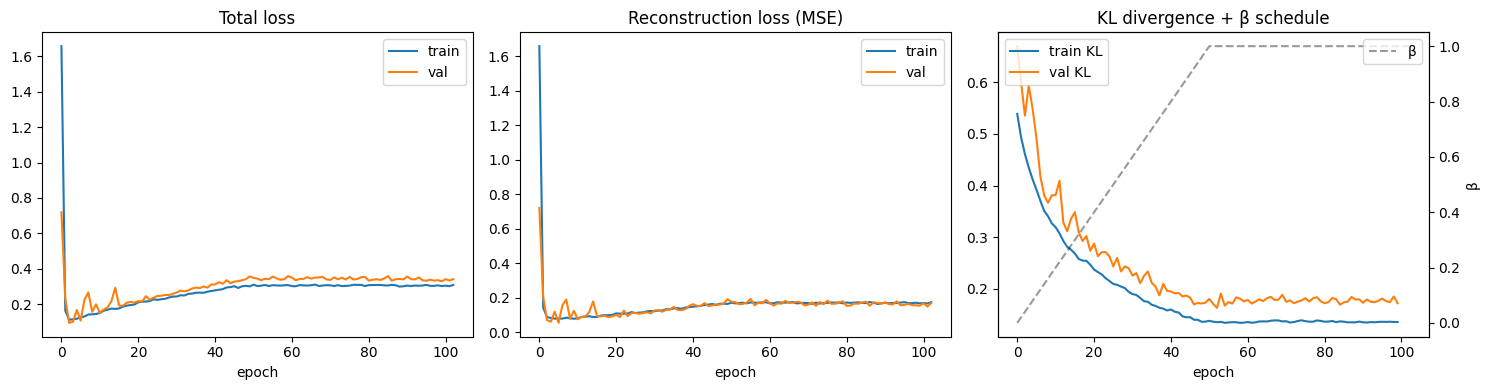

In [11]:
# --- Training curves ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["train_total"], label="train")
axes[0].plot(history["val_total"], label="val")
axes[0].set_title("Total loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history["train_recon"], label="train")
axes[1].plot(history["val_recon"], label="val")
axes[1].set_title("Reconstruction loss (MSE)")
axes[1].set_xlabel("epoch")
axes[1].legend()

axes[2].plot(history["train_kl"][3:], label="train KL")
axes[2].plot(history["val_kl"][3:], label="val KL")
ax2 = axes[2].twinx()
ax2.plot(history["beta"], "k--", alpha=0.4, label="β")
ax2.set_ylabel("β")
axes[2].set_title("KL divergence + β schedule")
axes[2].set_xlabel("epoch")
axes[2].legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [ ]:
plot_reconstructions(model, test_ds)

In [12]:
# --- Save model with metadata ---
import os

notebook_name = "notebook"
start_str = train_start.strftime("%Y%m%d_%H%M%S")
elapsed_str = f"{train_elapsed:.0f}s"
save_name = f"{notebook_name}_{start_str}_{elapsed_str}.pt"
save_path = os.path.join("models", save_name)

os.makedirs("models", exist_ok=True)
torch.save({
    "model_state_dict": model.state_dict(),
    "history": history,
    "config": {
        "USE_GLOBAL_ZSCORE": USE_GLOBAL_ZSCORE,
        "DRY_RUN": DRY_RUN,
        "EPOCHS": EPOCHS,
        "TARGET_BETA": TARGET_BETA,
        "BATCH_SIZE": BATCH_SIZE,
        "hidden_dim": 64,
        "latent_dim": 3,
        "seq_length": seq_len,
        "n_stim_channels": n_stim,
        "device": str(device),
    },
    "train_start": train_start.isoformat(),
    "train_elapsed_s": train_elapsed,
    "erk_mu": float(erk_mu),
    "erk_sigma": float(erk_sigma),
}, save_path)

print(f"Saved to {save_path}")

Saved to models/notebook_20260310_103528_138s.pt


In [ ]:

t_batch = list(test_loader)[0][0]


# Try different latent space compressions

## L.shape == 2

In [27]:
model = ConditionalBetaVAE(
    in_channels=in_ch, stim_channels=n_stim,
    hidden_dim=64, latent_dim=2, seq_length=seq_len, beta=1.0
).to(device)

# Quick forward pass sanity check
with torch.no_grad():
    recon, mu, logvar = model(enc_in.to(device), stim_cond.to(device))
print(f"Recon: {recon.shape}, mu: {mu.shape}, logvar: {logvar.shape}")
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Model on: {next(model.parameters()).device}")

Recon: torch.Size([64, 1, 40]), mu: torch.Size([64, 2]), logvar: torch.Size([64, 2])
Total params: 143,109
Model on: mps:0


In [ ]:
train_start = datetime.now()
t0 = time.time()

history = train(model, train_loader, val_loader,
                epochs=EPOCHS, target_beta=TARGET_BETA,
                warmup=WARMUP, patience=PATIENCE)

train_elapsed = time.time() - t0
print(f"\nTraining started: {train_start.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Training time: {train_elapsed:.1f}s ({train_elapsed/60:.1f} min)")

Epoch   0 | β=0.000 | Train: 0.9457 (r=0.9457 kl=1.0127) | Val: 0.7965 (r=0.7965 kl=0.8908)
Epoch  20 | β=0.400 | Train: 0.2551 (r=0.1342 kl=0.3023) | Val: 0.2786 (r=0.1455 kl=0.3327)
Epoch  40 | β=0.800 | Train: 0.3402 (r=0.1995 kl=0.1759) | Val: 0.4008 (r=0.1956 kl=0.2565)
Epoch  60 | β=1.000 | Train: 0.3564 (r=0.2252 kl=0.1312) | Val: 0.4374 (r=0.2489 kl=0.1884)
Epoch  80 | β=1.000 | Train: 0.3633 (r=0.2292 kl=0.1341) | Val: 0.4301 (r=0.2252 kl=0.2050)
Epoch 100 | β=1.000 | Train: 0.3623 (r=0.2286 kl=0.1337) | Val: 0.4257 (r=0.2249 kl=0.2008)
Early stopping at epoch 101

Training started: 2026-03-10 11:03:52
Training time: 137.1s (2.3 min)


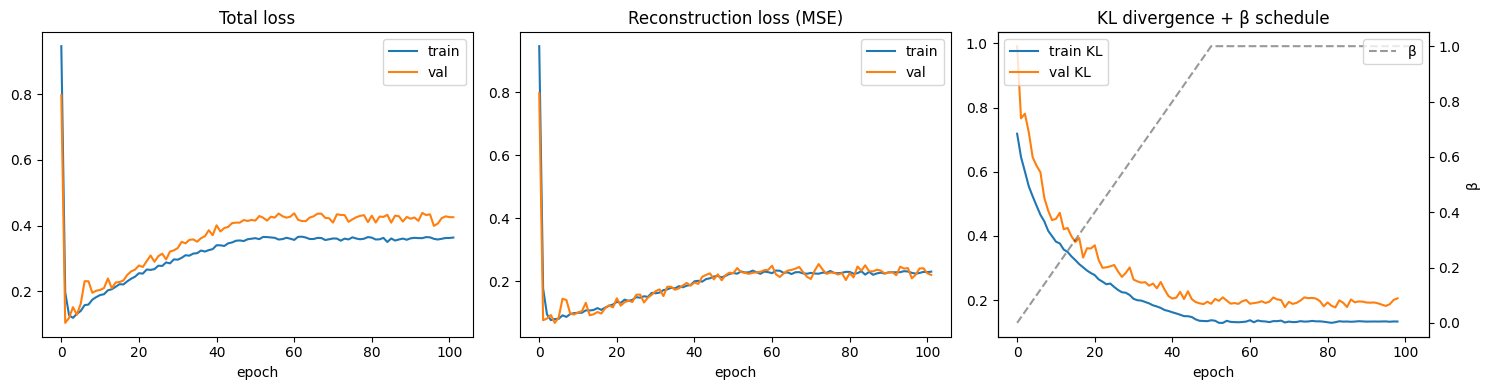

In [29]:
# --- Training curves ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["train_total"], label="train")
axes[0].plot(history["val_total"], label="val")
axes[0].set_title("Total loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history["train_recon"], label="train")
axes[1].plot(history["val_recon"], label="val")
axes[1].set_title("Reconstruction loss (MSE)")
axes[1].set_xlabel("epoch")
axes[1].legend()

axes[2].plot(history["train_kl"][3:], label="train KL")
axes[2].plot(history["val_kl"][3:], label="val KL")
ax2 = axes[2].twinx()
ax2.plot(history["beta"], "k--", alpha=0.4, label="β")
ax2.set_ylabel("β")
axes[2].set_title("KL divergence + β schedule")
axes[2].set_xlabel("epoch")
axes[2].legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [ ]:
plot_reconstructions(model, test_ds)

In [ ]:
# --- Save model with metadata ---
import os

notebook_name = "notebook"
start_str = train_start.strftime("%Y%m%d_%H%M%S")
elapsed_str = f"{train_elapsed:.0f}s"
save_name = f"{notebook_name}_{start_str}_{elapsed_str}.pt"
save_path = os.path.join("models", save_name)

os.makedirs("models", exist_ok=True)
torch.save({
    "model_state_dict": model.state_dict(),
    "history": history,
    "config": {
        "USE_GLOBAL_ZSCORE": USE_GLOBAL_ZSCORE,
        "DRY_RUN": DRY_RUN,
        "EPOCHS": EPOCHS,
        "TARGET_BETA": TARGET_BETA,
        "BATCH_SIZE": BATCH_SIZE,
        "hidden_dim": 64,
        "latent_dim": 3,
        "seq_length": seq_len,
        "n_stim_channels": n_stim,
        "device": str(device),
    },
    "train_start": train_start.isoformat(),
    "train_elapsed_s": train_elapsed,
    "erk_mu": float(erk_mu),
    "erk_sigma": float(erk_sigma),
}, save_path)

print(f"Saved to {save_path}")

Saved to models/notebook_20260310_103528_138s.pt


## L.shape == 4

In [33]:
model = ConditionalBetaVAE(
    in_channels=in_ch, stim_channels=n_stim,
    hidden_dim=64, latent_dim=4, seq_length=seq_len, beta=1.0
).to(device)

# Quick forward pass sanity check
with torch.no_grad():
    recon, mu, logvar = model(enc_in.to(device), stim_cond.to(device))
print(f"Recon: {recon.shape}, mu: {mu.shape}, logvar: {logvar.shape}")
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Model on: {next(model.parameters()).device}")

Recon: torch.Size([64, 1, 40]), mu: torch.Size([64, 4]), logvar: torch.Size([64, 4])
Total params: 143,497
Model on: mps:0


In [ ]:
# --- Run training ---
train_start = datetime.now()
t0 = time.time()

history = train(model, train_loader, val_loader,
                epochs=EPOCHS, target_beta=TARGET_BETA,
                warmup=WARMUP, patience=PATIENCE)

train_elapsed = time.time() - t0
print(f"\nTraining started: {train_start.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Training time: {train_elapsed:.1f}s ({train_elapsed/60:.1f} min)")

Epoch   0 | β=0.000 | Train: 1.1958 (r=1.1958 kl=0.6614) | Val: 0.1874 (r=0.1874 kl=2.4250)
Epoch  20 | β=0.400 | Train: 0.1808 (r=0.0922 kl=0.2216) | Val: 0.1919 (r=0.0891 kl=0.2571)
Epoch  40 | β=0.800 | Train: 0.2383 (r=0.1182 kl=0.1501) | Val: 0.2558 (r=0.1067 kl=0.1864)
Epoch  60 | β=1.000 | Train: 0.2663 (r=0.1384 kl=0.1278) | Val: 0.2955 (r=0.1300 kl=0.1655)
Epoch  80 | β=1.000 | Train: 0.2664 (r=0.1387 kl=0.1278) | Val: 0.2890 (r=0.1288 kl=0.1602)
Epoch 100 | β=1.000 | Train: 0.2634 (r=0.1355 kl=0.1279) | Val: 0.2949 (r=0.1377 kl=0.1572)
Early stopping at epoch 103

Training started: 2026-03-10 11:16:35
Training time: 146.8s (2.4 min)


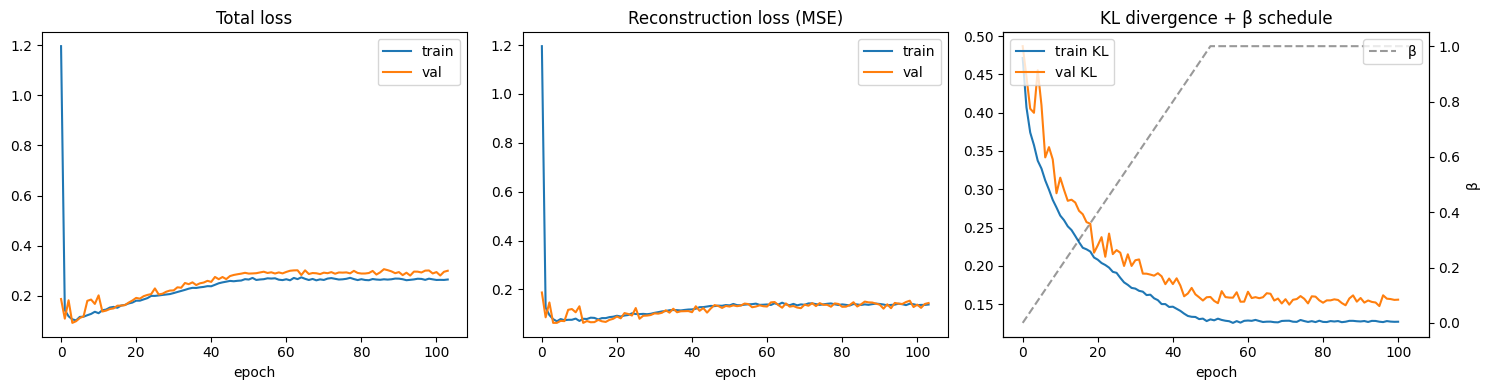

In [35]:
# --- Training curves ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["train_total"], label="train")
axes[0].plot(history["val_total"], label="val")
axes[0].set_title("Total loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history["train_recon"], label="train")
axes[1].plot(history["val_recon"], label="val")
axes[1].set_title("Reconstruction loss (MSE)")
axes[1].set_xlabel("epoch")
axes[1].legend()

axes[2].plot(history["train_kl"][3:], label="train KL")
axes[2].plot(history["val_kl"][3:], label="val KL")
ax2 = axes[2].twinx()
ax2.plot(history["beta"], "k--", alpha=0.4, label="β")
ax2.set_ylabel("β")
axes[2].set_title("KL divergence + β schedule")
axes[2].set_xlabel("epoch")
axes[2].legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

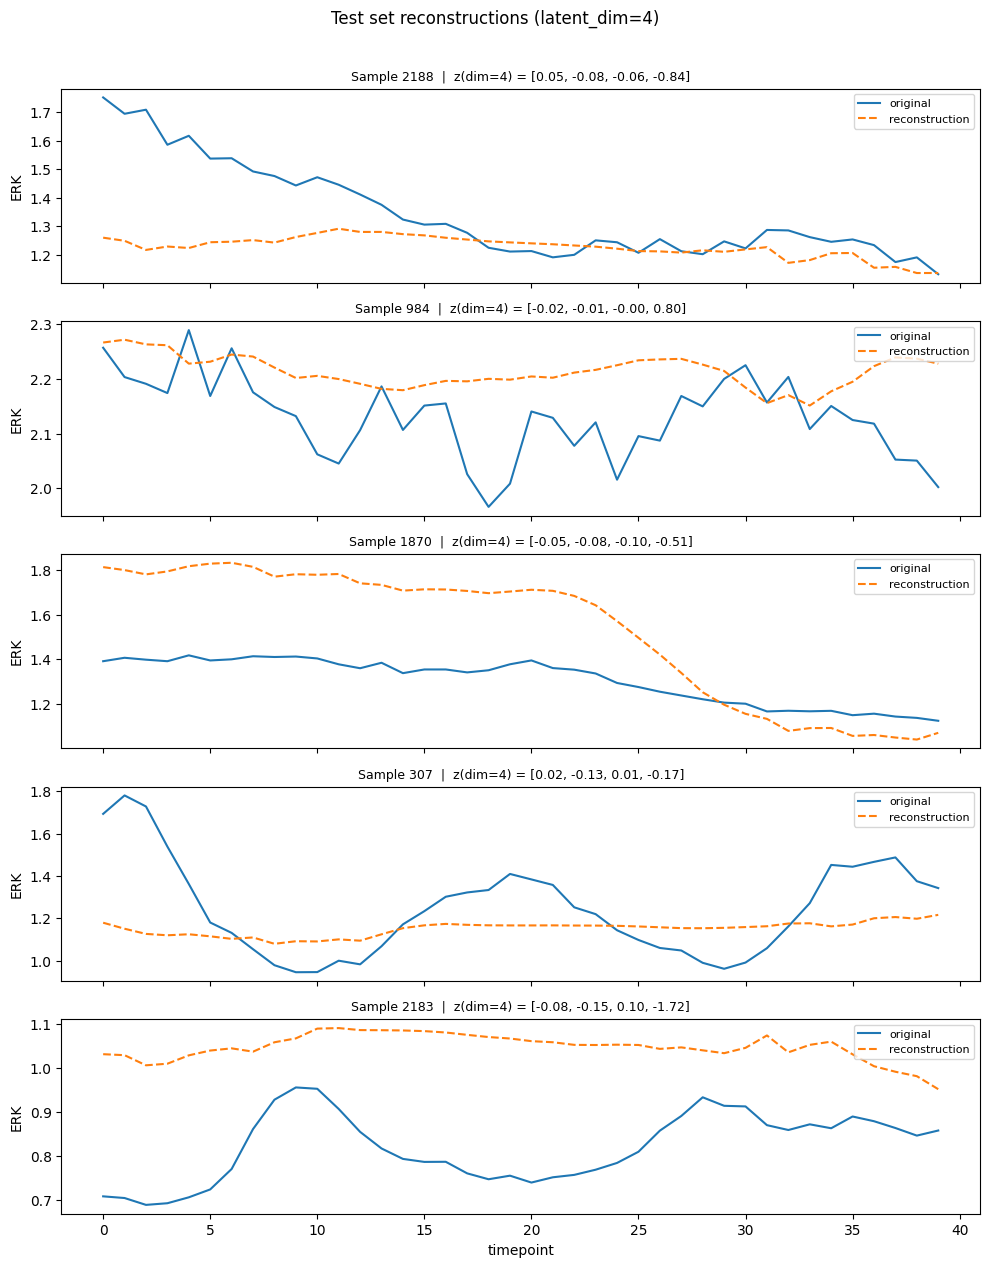

In [38]:
plot_reconstructions(model, test_ds)

## L.shape == 10

In [ ]:
model = ConditionalBetaVAE(
    in_channels=in_ch, stim_channels=n_stim,
    hidden_dim=64, latent_dim=10, seq_length=seq_len, beta=1.0
).to(device)

# Quick forward pass sanity check
with torch.no_grad():
    recon, mu, logvar = model(enc_in.to(device), stim_cond.to(device))
print(f"Recon: {recon.shape}, mu: {mu.shape}, logvar: {logvar.shape}")
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Model on: {next(model.parameters()).device}")

Recon: torch.Size([64, 1, 40]), mu: torch.Size([64, 4]), logvar: torch.Size([64, 4])
Total params: 143,497
Model on: mps:0


In [ ]:
# --- Run training ---
train_start = datetime.now()
t0 = time.time()

history = train(model, train_loader, val_loader,
                epochs=EPOCHS, target_beta=TARGET_BETA,
                warmup=WARMUP, patience=PATIENCE)

train_elapsed = time.time() - t0
print(f"\nTraining started: {train_start.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Training time: {train_elapsed:.1f}s ({train_elapsed/60:.1f} min)")

Epoch   0 | β=0.000 | Train: 1.1958 (r=1.1958 kl=0.6614) | Val: 0.1874 (r=0.1874 kl=2.4250)
Epoch  20 | β=0.400 | Train: 0.1808 (r=0.0922 kl=0.2216) | Val: 0.1919 (r=0.0891 kl=0.2571)
Epoch  40 | β=0.800 | Train: 0.2383 (r=0.1182 kl=0.1501) | Val: 0.2558 (r=0.1067 kl=0.1864)
Epoch  60 | β=1.000 | Train: 0.2663 (r=0.1384 kl=0.1278) | Val: 0.2955 (r=0.1300 kl=0.1655)
Epoch  80 | β=1.000 | Train: 0.2664 (r=0.1387 kl=0.1278) | Val: 0.2890 (r=0.1288 kl=0.1602)
Epoch 100 | β=1.000 | Train: 0.2634 (r=0.1355 kl=0.1279) | Val: 0.2949 (r=0.1377 kl=0.1572)
Early stopping at epoch 103

Training started: 2026-03-10 11:16:35
Training time: 146.8s (2.4 min)


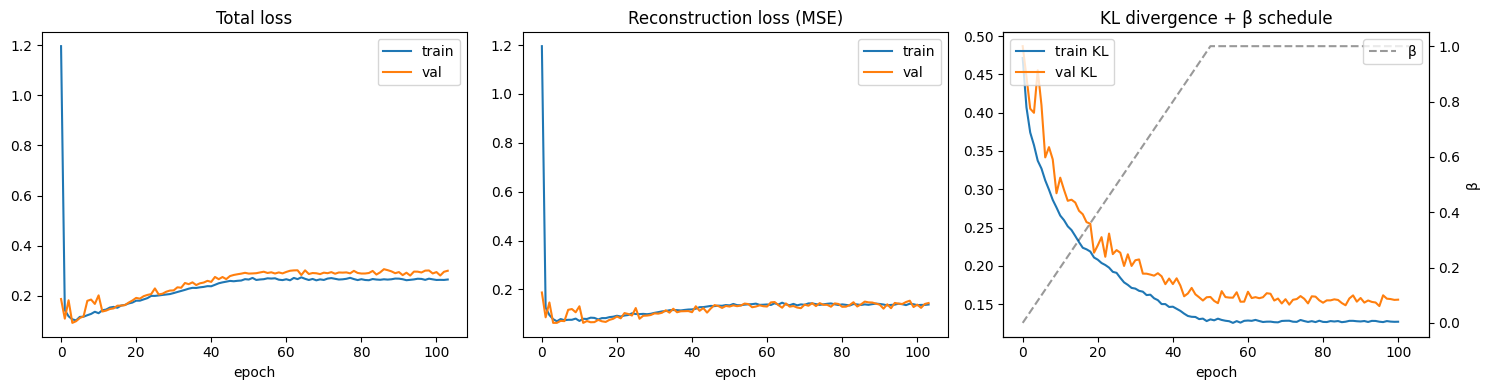

In [ ]:
# --- Training curves ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["train_total"], label="train")
axes[0].plot(history["val_total"], label="val")
axes[0].set_title("Total loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history["train_recon"], label="train")
axes[1].plot(history["val_recon"], label="val")
axes[1].set_title("Reconstruction loss (MSE)")
axes[1].set_xlabel("epoch")
axes[1].legend()

axes[2].plot(history["train_kl"][3:], label="train KL")
axes[2].plot(history["val_kl"][3:], label="val KL")
ax2 = axes[2].twinx()
ax2.plot(history["beta"], "k--", alpha=0.4, label="β")
ax2.set_ylabel("β")
axes[2].set_title("KL divergence + β schedule")
axes[2].set_xlabel("epoch")
axes[2].legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

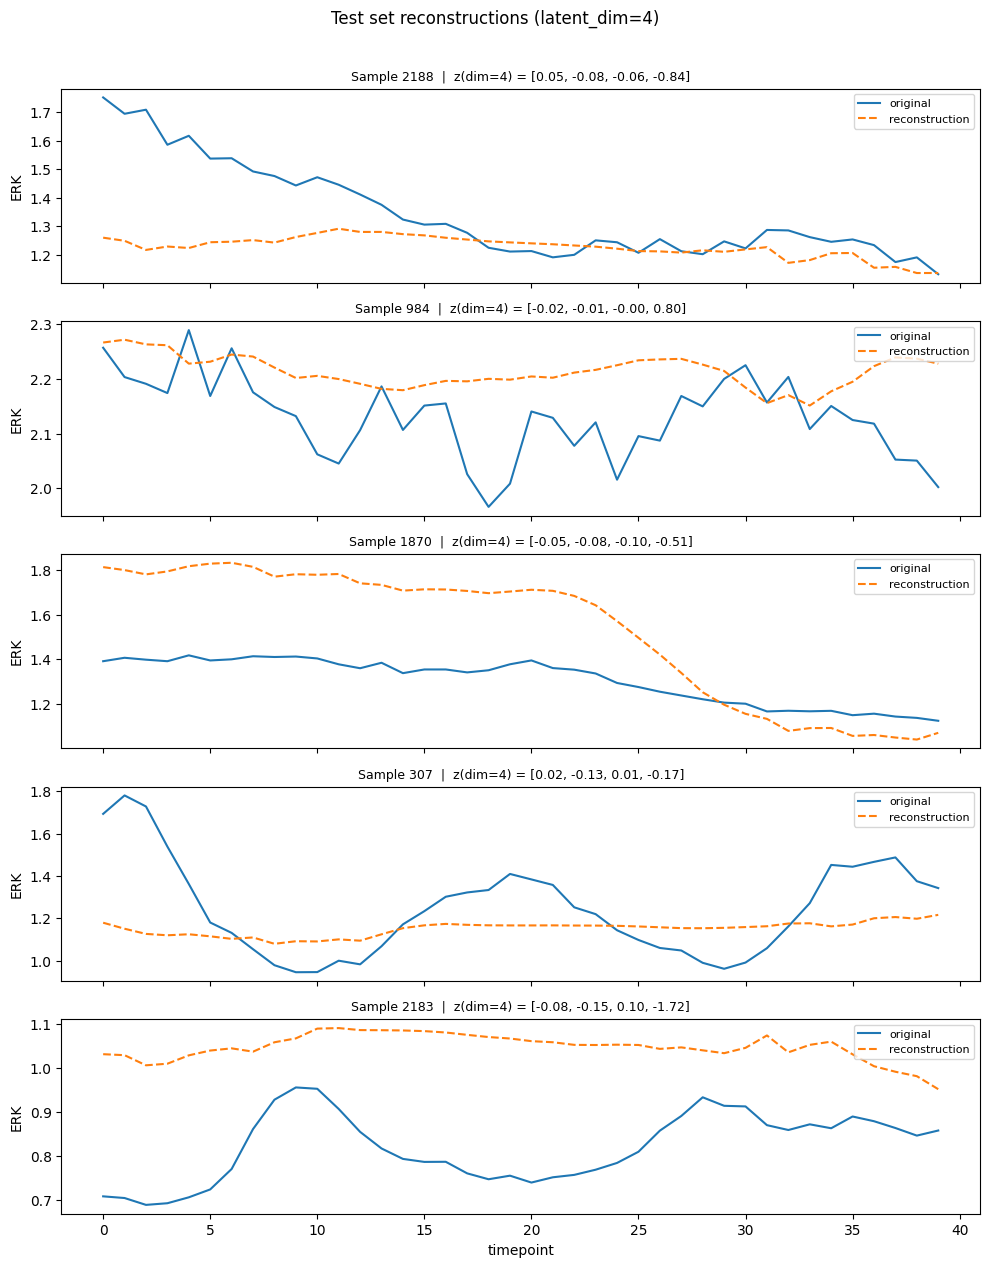

In [ ]:
plot_reconstructions(model, test_ds)

In [43]:
import ipywidgets as widgets
from IPython.display import display

def interactive_latent_explorer(model, test_dataset, device=device, z_range=(-3.0, 3.0)):
    """Interactive widget: pick a test sample, perturb its latent dims with sliders,
    and see original vs perturbed reconstruction side-by-side.
    Works with any latent_dim."""
    model.eval()

    # --- Pre-encode all test samples to find latent dim ---
    sample_enc, sample_stim, sample_target = test_dataset[0]
    with torch.no_grad():
        mu0, _ = model.encoder(sample_enc.unsqueeze(0).to(device))
    latent_dim = mu0.shape[-1]

    # --- Widgets ---
    sample_slider = widgets.IntSlider(
        value=0, min=0, max=len(test_dataset) - 1, step=1,
        description="Sample:", style={"description_width": "60px"},
        layout=widgets.Layout(width="400px"),
    )
    z_sliders = []
    for d in range(latent_dim):
        s = widgets.FloatSlider(
            value=0.0, min=z_range[0], max=z_range[1], step=0.05,
            description=f"z[{d}]:", readout_format=".2f",
            style={"description_width": "50px"},
            layout=widgets.Layout(width="400px"),
        )
        z_sliders.append(s)

    reset_btn = widgets.Button(description="Reset to encoded z", layout=widgets.Layout(width="180px"))
    output = widgets.Output()

    def _encode_sample(idx):
        enc_in, stim_cond, target = test_dataset[idx]
        enc_in_d = enc_in.unsqueeze(0).to(device)
        stim_d = stim_cond.unsqueeze(0).to(device)
        with torch.no_grad():
            mu, logvar = model.encoder(enc_in_d)
        return mu, stim_d, target.squeeze().numpy()

    def _update(*args):
        output.clear_output(wait=True)
        idx = sample_slider.value
        mu, stim_d, target_np = _encode_sample(idx)

        z_perturbed = torch.tensor([[s.value for s in z_sliders]], device=device, dtype=mu.dtype)

        with torch.no_grad():
            recon_orig = model.decoder(mu, stim_d).squeeze().cpu().numpy()
            recon_pert = model.decoder(z_perturbed, stim_d).squeeze().cpu().numpy()

        mu_np = mu.squeeze().cpu().numpy()

        with output:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.5), sharey=True)

            ax1.plot(target_np, "k-", linewidth=1.5, label="original")
            ax1.plot(recon_orig, "b--", linewidth=1.5, label="reconstruction")
            ax1.set_title(f"Original encoding  z=[{', '.join(f'{v:.2f}' for v in mu_np)}]", fontsize=9)
            ax1.set_xlabel("timepoint")
            ax1.set_ylabel("ERK")
            ax1.legend(fontsize=8)

            ax2.plot(target_np, "k-", linewidth=1.5, alpha=0.4, label="original")
            ax2.plot(recon_pert, "r--", linewidth=1.5, label="perturbed recon")
            z_vals = [s.value for s in z_sliders]
            ax2.set_title(f"Perturbed  z=[{', '.join(f'{v:.2f}' for v in z_vals)}]", fontsize=9)
            ax2.set_xlabel("timepoint")
            ax2.legend(fontsize=8)

            plt.tight_layout()
            plt.show()

    def _on_sample_change(change):
        mu, _, _ = _encode_sample(change["new"])
        mu_np = mu.squeeze().cpu().numpy()
        for d, s in enumerate(z_sliders):
            s.value = float(mu_np[d])

    def _reset(btn):
        mu, _, _ = _encode_sample(sample_slider.value)
        mu_np = mu.squeeze().cpu().numpy()
        for d, s in enumerate(z_sliders):
            s.value = float(mu_np[d])

    # --- Wire up observers ---
    sample_slider.observe(_on_sample_change, names="value")
    for s in z_sliders:
        s.observe(_update, names="value")
    reset_btn.on_click(_reset)

    # Initialise sliders to first sample's encoding
    _on_sample_change({"new": 0})

    controls = widgets.VBox(
        [sample_slider, widgets.HTML("<b>Latent space:</b>")] + z_sliders + [reset_btn]
    )
    display(widgets.VBox([controls, output]))

In [ ]:
interactive_latent_explorer(model, test_ds)